# 第4章 神经网络的学习

- 📅 2026-07-11
- 🏷️ 深度学习, 损失函数, 梯度下降, 反向传播
- 📖 参考：《深度学习入门：基于Python的理论与实现》斋藤康毅
- 🔗 前章：[第3章 神经网络](./neural-network.ipynb)

## 4.1 从数据中学习

第2章感知机的权重是**人手工算的**，第3章搭好了神经网络架子，但权重是**随机给的**。

第4章要解决的：**让神经网络自己从数据中学习权重**。

```
训练数据 → 前向传播（预测）→ 算损失（差多少）→ 梯度（往哪改）→ 更新权重 → 重复
   ↑                                                         ↓
   └──────────────── 这就是"学习" ─────────────────────────────┘
```

- **训练数据**：用来学习权重的数据
- **测试数据**：用来评价模型泛化能力的数据（不能用于训练！）
- **泛化能力**：对没见过的数据也能正确处理的能力

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

## 4.2 损失函数

**损失函数**衡量神经网络的预测有多糟糕。损失越小 → 模型越好。

> 为什么不直接用「识别精度」当指标？
> 精度在参数微调时**不连续变化**（类似阶跃函数），导数处处为 0 → 无法用梯度下降。
> 损失函数是**连续可微**的，参数的小变化能反映在损失上。

### 4.2.1 均方误差 (Mean Squared Error)

$$E = \frac{1}{2}\sum_{k}(y_k - t_k)^2$$

- $y_k$：神经网络的输出
- $t_k$：监督数据（one-hot 编码，正确标签为 1，其余为 0）

In [2]:
def mean_squared_error(y, t):
    """均方误差"""
    return 0.5 * np.sum((y - t) ** 2)

# 测试：one-hot 编码 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0] 表示数字 "2"
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])          # 正确答案：2

# 预测：2 的概率最高 → 损失小
y_good = np.array([0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0])
print('好预测的 MSE:', mean_squared_error(y_good, t))

# 预测：7 的概率最高 → 损失大
y_bad = np.array([0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0])
print('差预测的 MSE:', mean_squared_error(y_bad, t))

好预测的 MSE: 0.09750000000000003
差预测的 MSE: 0.5975


### 4.2.2 交叉熵误差 (Cross Entropy Error)

$$E = -\sum_{k}t_k \log y_k$$

只关注**正确标签**对应的输出。正确标签的 $t_k = 1$，所以 $E = -\log y_{correct}$。

正确标签的预测概率越接近 1 → 损失越小（-log(1) = 0）。

In [3]:
def cross_entropy_error(y, t):
    """交叉熵误差"""
    delta = 1e-7                            # 防止 log(0) = -inf
    return -np.sum(t * np.log(y + delta))

print('好预测的交叉熵:', cross_entropy_error(y_good, t))
print('差预测的交叉熵:', cross_entropy_error(y_bad, t))
print()
print(f'-log(0.6) = {-np.log(0.6):.4f}  ← 预测对，概率高，损失小')
print(f'-log(0.1) = {-np.log(0.1):.4f}  ← 预测错，概率低，损失大')

好预测的交叉熵: 0.510825457099338
差预测的交叉熵: 2.302584092994546

-log(0.6) = 0.5108  ← 预测对，概率高，损失小
-log(0.1) = 2.3026  ← 预测错，概率低，损失大


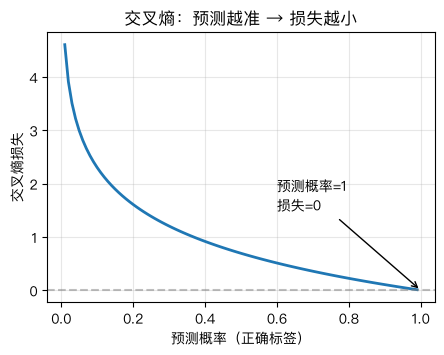

In [4]:
# 可视化：-log(x) 的形状
x = np.arange(0.01, 1.0, 0.01)
y = -np.log(x)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, y, linewidth=2)
ax.set_xlabel('预测概率（正确标签）')
ax.set_ylabel('交叉熵损失')
ax.set_title('交叉熵：预测越准 → 损失越小')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.annotate('预测概率=1\n损失=0', xy=(1, 0), xytext=(0.6, 1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

### 4.2.3 mini-batch 学习

全量数据算损失太慢。每次随机抽一小批（mini-batch）来算：

$$E = -\frac{1}{N}\sum_{n}\sum_{k}t_{nk} \log y_{nk}$$

In [5]:
def cross_entropy_error_batch(y, t):
    """mini-batch 版交叉熵误差"""
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size


# 测试：3 个样本的批处理
y_batch = np.array([[0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0],   # 预测 2
                    [0.1, 0.05, 0.1, 0.0, 0.1, 0.1, 0.0, 0.5, 0.05, 0.0],   # 预测 7
                    [0.0, 0.0, 0.0, 0.0, 0.9, 0.0, 0.0, 0.05, 0.05, 0.0]])  # 预测 4
t_batch = np.array([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],    # 答案：2
                    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],    # 答案：2（第2个错了）
                    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])   # 答案：4

print('批量交叉熵误差:', cross_entropy_error_batch(y_batch, t_batch))

批量交叉熵误差: 0.9729233182135352


## 4.3 数值微分

梯度下降需要**导数**。计算机不会解析求导，用**数值微分**来近似：

$$\frac{df}{dx} \approx \frac{f(x+h) - f(x-h)}{2h}$$

用**中心差分**（两边各取一个小步长），比向前差分误差更小。$h = 10^{-4}$ 是一个经验上较好的值。

In [6]:
def numerical_diff(f, x):
    """中心差分数值微分"""
    h = 1e-4
    return (f(x + h) - f(x - h)) / (2 * h)


# 测试 f(x) = x²，导数应该是 2x
def f1(x):
    return x ** 2

x_test = 3.0
num = numerical_diff(f1, x_test)
true = 2 * x_test
print(f'f(x)=x² 在 x=3 处的数值导数: {num:.10f}')
print(f'真实导数 2x: {true}')
print(f'误差: {abs(num - true):.2e}')

f(x)=x² 在 x=3 处的数值导数: 6.0000000000
真实导数 2x: 6.0
误差: 1.27e-11


## 4.4 梯度

### 4.4.1 梯度是什么

多元函数的梯度 = 所有变量的偏导数组成的向量：

$$\nabla f = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}\right)$$

梯度指向函数值**增加最快**的方向 → 反过来走就是下降最快的方向。

In [7]:
def numerical_gradient(f, x):
    """数值计算梯度（支持任意维度数组）"""
    h = 1e-4
    grad = np.zeros_like(x)

    # 用 nditer 遍历所有元素，支持二维矩阵
    it = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]

        x[idx] = tmp_val + h
        fxh1 = f(x)

        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val   # 还原
        it.iternext()

    return grad


# 测试 f(x₁,x₂) = x₁² + x₂²，梯度 = (2x₁, 2x₂)
def f2(x):
    return x[0]**2 + x[1]**2

print('1D 梯度:', numerical_gradient(f2, np.array([3.0, 4.0])))
print('期望: (6, 8)')

# 测试 2D 矩阵梯度
W = np.array([[1.0, 2.0], [3.0, 4.0]])
def f_matrix(w):
    return np.sum(w ** 2)
print('2D 梯度:\n', numerical_gradient(f_matrix, W))
print('期望: [[2, 4], [6, 8]]')


1D 梯度: [6. 8.]
期望: (6, 8)
2D 梯度:
 [[2. 4.]
 [6. 8.]]
期望: [[2, 4], [6, 8]]


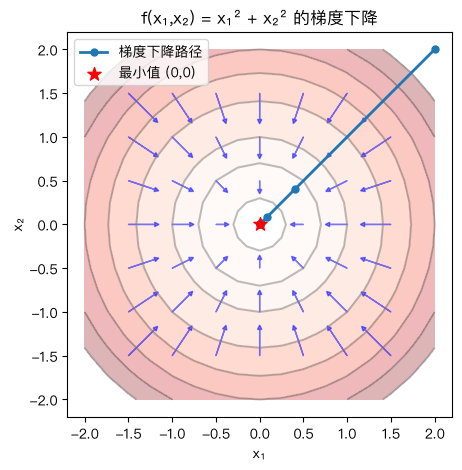

In [8]:
# 可视化：梯度和梯度下降
def gradient_descent_visualize():
    x0 = np.arange(-2, 2.25, 0.25)
    x1 = np.arange(-2, 2.25, 0.25)
    X, Y = np.meshgrid(x0, x1)
    Z = X**2 + Y**2
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # 画等高线
    levels = [0.1, 0.5, 1, 2, 3, 4, 5, 6]
    ax.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.5)
    ax.contourf(X, Y, Z, levels=levels, cmap='Reds', alpha=0.3)
    
    # 在格点上画梯度向量
    for x in np.arange(-1.5, 1.75, 0.5):
        for y in np.arange(-1.5, 1.75, 0.5):
            g = numerical_gradient(f2, np.array([x, y]))
            ax.arrow(x, y, -g[0]*0.1, -g[1]*0.1, head_width=0.05, head_length=0.05, fc='blue', ec='blue', alpha=0.5)
    
    # 从 (2,2) 开始梯度下降
    x = np.array([2.0, 2.0])
    path_x, path_y = [x[0]], [x[1]]
    for _ in range(10):
        g = numerical_gradient(f2, x)
        x = x - 0.4 * g
        path_x.append(x[0]); path_y.append(x[1])
    
    ax.plot(path_x, path_y, 'C0-o', markersize=5, linewidth=2, label='梯度下降路径')
    ax.scatter([0], [0], c='red', s=100, marker='*', zorder=10, label='最小值 (0,0)')
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title('f(x₁,x₂) = x₁² + x₂² 的梯度下降')
    ax.legend()
    ax.set_aspect('equal')
    plt.show()

gradient_descent_visualize()

### 4.4.2 梯度法（Gradient Descent）

沿梯度**反方向**重复更新参数，逐步逼近最小值：

$$\mathbf{x}_{new} = \mathbf{x}_{old} - \eta \cdot \nabla f$$

- **η（学习率）**：决定每次更新多大的步长
  - 太大 → 发散，在最小值周围震荡
  - 太小 → 收敛太慢

In [9]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    """梯度下降法"""
    x = init_x.copy()
    x_history = [x.copy()]

    for _ in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
        x_history.append(x.copy())

    return x, np.array(x_history)

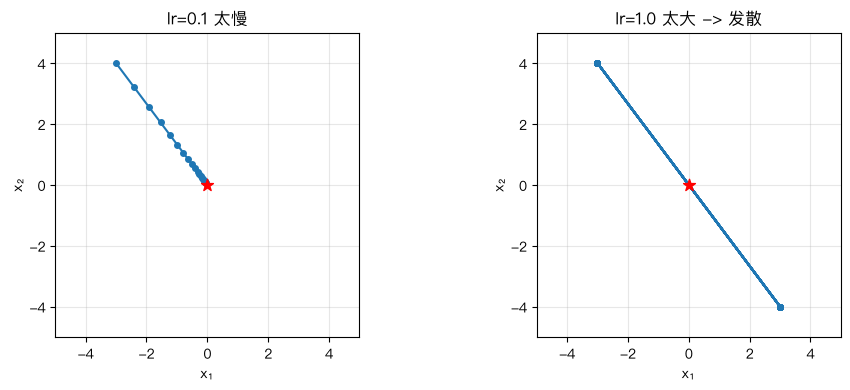

初始位置: [-3.  4.], 最终位置: [-0.      0.0001], f(x) = 0.000000


In [10]:
# 对比不同学习率的效果
init_x = np.array([-3.0, 4.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, lr, title in [(axes[0], 0.1, 'lr=0.1 太慢'), (axes[1], 1.0, 'lr=1.0 太大 -> 发散')]:
    _, history = gradient_descent(f2, init_x, lr=lr, step_num=20)
    ax.plot(history[:, 0], history[:, 1], 'o-', markersize=4, linewidth=1.5)
    ax.scatter(0, 0, c='red', s=80, marker='*', zorder=10)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 合适的学习率
final, history = gradient_descent(f2, init_x, lr=0.1, step_num=50)
print(f'初始位置: {init_x}, 最终位置: {np.round(final, 4)}, f(x) = {f2(final):.6f}')

## 4.5 学习算法的实现

### TwoLayerNet 类

`input(784) → hidden(50) → output(10)` 的 2 层网络，用数值微分计算梯度。

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    c = np.max(x)
    exp_a = np.exp(x - c)
    return exp_a / np.sum(exp_a)

In [12]:
class TwoLayerNet:
    """2 层神经网络：input → hidden(sigmoid) → output(softmax)"""
    
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 初始化权重和偏置
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
    
    def predict(self, x):
        """前向传播"""
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        return y
    
    def loss(self, x, t):
        """计算损失"""
        y = self.predict(x)
        return cross_entropy_error_batch(y, t)
    
    def accuracy(self, x, t):
        """计算识别精度"""
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1) if t.ndim != 1 else t
        return np.sum(y == t) / float(x.shape[0])
    
    def numerical_gradient(self, x, t):
        """用数值微分计算所有参数的梯度"""
        loss_W = lambda W: self.loss(x, t)
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads


# 验证
net = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
x_dummy = np.random.randn(5, 784)
t_dummy = np.eye(10)[[2, 5, 0, 9, 3]]  # one-hot: 5个样本

print('预测概率形状:', net.predict(x_dummy).shape)   # (5, 10)
print('损失:', net.loss(x_dummy, t_dummy))
print('精度:', net.accuracy(x_dummy, t_dummy))

预测概率形状: (5, 10)
损失: 2.315640747316586
精度: 0.0


### mini-batch 学习（SGD）

完整的学习循环：

1. 随机选 mini-batch
2. 计算梯度
3. 更新参数
4. 重复

In [ ]:
# 用模拟数据演示完整训练流程
# 实际 MNIST 训练需要下载数据和预训练权重

def simulate_training():
    """模拟 MNIST 训练（使用随机数据理解流程）"""
    # 模拟数据：1000 个样本，784 维 → 10 类
    n_samples = 1000
    np.random.seed(42)
    
    # 伪造一些有模式的数据（不是完全随机）
    X_train = np.random.randn(n_samples, 784)
    # 随机标签
    labels = np.random.randint(0, 10, n_samples)
    T_train = np.eye(10)[labels]
    
    # 网络初始化
    network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
    
    # 超参数
    iters_num = 1000
    train_size = X_train.shape[0]
    batch_size = 100
    learning_rate = 0.1
    
    train_loss_list = []
    train_acc_list = []
    
    for i in range(iters_num):
        # 1. 随机选 mini-batch
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = X_train[batch_mask]
        t_batch = T_train[batch_mask]
        
        # 2. 计算梯度
        grad = network.numerical_gradient(x_batch, t_batch)
        
        # 3. 更新参数（SGD）
        for key in ('W1', 'b1', 'W2', 'b2'):
            network.params[key] -= learning_rate * grad[key]
        
        # 4. 记录损失
        loss = network.loss(x_batch, t_batch)
        train_loss_list.append(loss)
        
        # 每个 epoch（所有数据过一遍）记录精度
        if i % 100 == 0:
            acc = network.accuracy(X_train, T_train)
            train_acc_list.append(acc)
            print(f'iter {i:4d} | loss: {loss:.4f} | train acc: {acc:.4f}')
    
    return train_loss_list, train_acc_list

train_loss_list, train_acc_list = simulate_training()

iter    0 | loss: 2.2883 | train acc: 0.0950


In [ ]:
# 可视化训练过程
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_loss_list)
axes[0].set_xlabel('迭代次数')
axes[0].set_ylabel('损失')
axes[0].set_title('训练损失下降曲线')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(0, len(train_loss_list), 100), train_acc_list, 'C3-o')
axes[1].set_xlabel('迭代次数')
axes[1].set_ylabel('训练精度')
axes[1].set_title('训练精度上升曲线')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 如果用真实 MNIST 完整训练（概念代码）

```python
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

train_loss_list = []
train_acc_list = []
test_acc_list = []

iters_num = 10000
batch_size = 100
learning_rate = 0.1

# 平均每个 epoch 的重复次数
iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    grad = network.numerical_gradient(x_batch, t_batch)
    
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    # 每个 epoch 记录训练和测试精度
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f'train acc: {train_acc:.4f}, test acc: {test_acc:.4f}')
```

> **书中结果**：训练精度 ~0.94，测试精度 ~0.92

## 本章小结

| 概念 | 说明 |
|------|------|
| 损失函数 | 衡量预测有多糟糕（MSE / 交叉熵） |
| mini-batch | 随机抽一小批数据算梯度，不用等全量 |
| 数值微分 | $\frac{f(x+h)-f(x-h)}{2h}$，近似计算导数 |
| 梯度 | 多个偏导数组成的向量，指向增加最快的方向 |
| SGD | 沿梯度反方向更新参数：$W \leftarrow W - \eta \nabla L$ |
| 学习率 | 控制更新步长，太大发散太小收敛慢（需要调） |
| epoch | 所有训练数据都用过一次 |

### 四步学习法（记住就行）

```
1. mini-batch ──→ 2. 算梯度 ──→ 3. 更新参数 ──→ 4. 重复
       ↑                                  ↓
       └────────── SGD 循环 ──────────────┘
```

### 全书脉络

| 章节 | 进展 |
|------|------|
| 第2章 | 感知机 — 人工设定权重 |
| 第3章 | 神经网络 — 搭好前向传播架子 |
| **第4章** | **神经网络的学习 — 自动学习权重！** |
| 第5章 | 误差反向传播 — 快速算梯度（不再用慢速数值微分） |

> 第4章用数值微分算梯度**能工作但太慢**。下一章「误差反向传播」用链式法则高速求梯度——这是现代深度学习真正起飞的关键。